- [Accelerate](https://huggingface.co/docs/accelerate/index)
- [Runpod with your IDE](https://docs.runpod.io/pods/configuration/connect-to-ide)

## Distributed Model Parrelelization

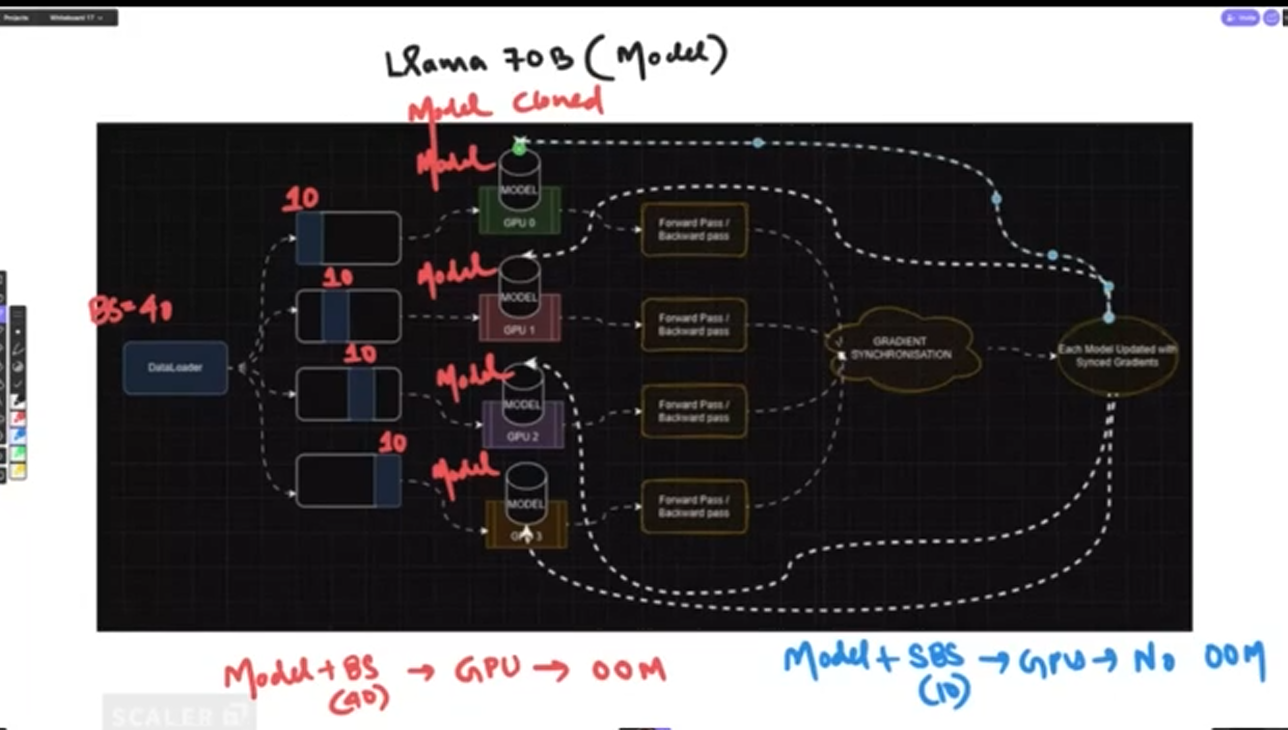

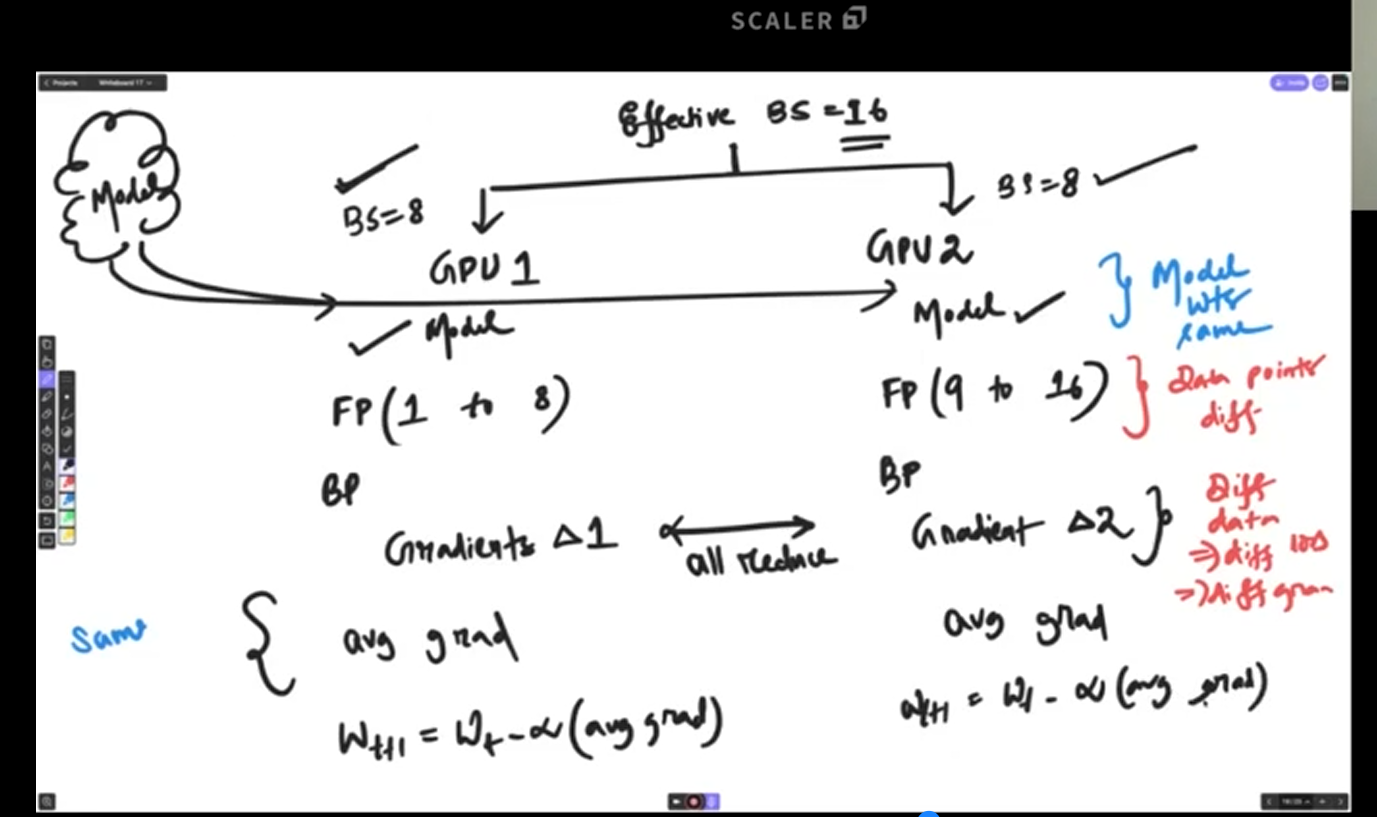

# Distributed Training for Large Language Models (LLMs)

# Why Distributed Training?

A single GPU cannot train modern LLMs because memory requirements become enormous.

GPU memory is consumed by:

- **Model Parameters**
- **Gradients**
- **Optimizer States**

For the Adam optimizer:

- Parameters
- Gradients
- First Moment (m)
- Second Moment (v)

Approximate memory:

\[
\text{Memory} \approx (2 + 2 + K)\Psi
\]

where:

- \(\Psi\) = Number of parameters
- \(K \approx 12\) bytes (Adam optimizer states)

### Rule of Thumb

Approximately **16 GB VRAM is required per 1B parameters** for full fine-tuning.

Examples:

| Model | Approximate Memory |
|--------|--------------------|
| 7B | ~112 GB |
| 70B | >1 TB |

Since a single GPU cannot provide this much memory, **distributed training becomes necessary**.

---

# Two Ways to Train Bigger Models

## 1. Reduce What You Train

Instead of updating every parameter, train only a small subset.

Examples:

- LoRA
- QLoRA
- Adapters

Advantages:

- Much lower GPU memory
- Faster training
- Smaller checkpoints

---

## 2. Distribute the Model

Instead of reducing trainable parameters, distribute computation across multiple GPUs.

Examples:

- DDP
- FSDP
- DeepSpeed ZeRO
- Tensor Parallelism
- Pipeline Parallelism

---

# NCCL

**NCCL = NVIDIA Collective Communication Library**

NCCL provides communication primitives between GPUs.

Almost every distributed training algorithm is built using these primitives.

---

# Important Collective Operations

## 1. Reduce

Many GPUs → One GPU

Example

```
GPU0 : 2
GPU1 : 3
GPU2 : 5

Reduce (SUM)

GPU0 : 10
GPU1 : unchanged
GPU2 : unchanged
```

Used when only one GPU requires the final result.

---

## 2. Broadcast

One GPU → All GPUs

```
GPU0 (weights)

      ↓

GPU1
GPU2
GPU3
```

Used after model initialization so every GPU starts with identical weights.

---

## 3. AllReduce ⭐⭐⭐

Every GPU contributes.

Every GPU receives the reduced result.

```
GPU0 gradients
GPU1 gradients
GPU2 gradients

        ↓

      SUM

        ↓

GPU0 gets result
GPU1 gets result
GPU2 gets result
```

Most important operation in DDP.

**Interview line**

> DDP synchronizes gradients using **AllReduce** after backpropagation.

---

## 4. AllGather ⭐⭐⭐

Each GPU owns only part of a tensor.

AllGather reconstructs the complete tensor.

```
GPU0 : A
GPU1 : B
GPU2 : C

      ↓

GPU0 : ABC
GPU1 : ABC
GPU2 : ABC
```

Used heavily in FSDP.

---

## 5. ReduceScatter ⭐⭐⭐

Opposite of AllGather.

Steps:

```
Reduce

↓

Scatter
```

Each GPU keeps only its own reduced shard.

Used heavily in FSDP.

---

# Data Parallelism

Each GPU stores:

- Complete model
- Different mini-batch

Example

```
GPU0

Model
Batch 1

----------------

GPU1

Model
Batch 2
```

Workflow

```
Forward

↓

Backward

↓

Synchronize Gradients

↓

Optimizer Step
```

---

# Distributed Data Parallel (DDP)

Most common PyTorch distributed training strategy.

Each GPU stores:

- Full Parameters
- Full Gradients
- Full Optimizer States

Nothing is sharded.

---

## DDP Workflow

```
Broadcast Model

↓

Forward

↓

Backward

↓

Gradient AllReduce

↓

Optimizer Step
```

---

## Communication Used

✅ AllReduce

```
Forward

↓

Backward

↓

AllReduce Gradients

↓

Update Parameters
```

---

## Why AllReduce?

Each GPU computes gradients using different mini-batches.

AllReduce averages gradients.

Therefore every GPU updates using identical gradients.

All model replicas remain synchronized.

---

## DDP Memory

Each GPU stores

- Full Parameters
- Full Gradients
- Full Optimizer States

Approximate memory:

\[
(2 + 2 + K)\Psi
\]

No memory savings.

---

## Advantages

- Simple
- Fast
- Easy to use
- Minimal communication

---

## Limitations

Cannot train models larger than GPU memory.

---

# ZeRO

**ZeRO = Zero Redundancy Optimizer**

Goal:

Remove duplicated memory across GPUs.

Instead of every GPU storing everything, each GPU stores only a portion.

---

## ZeRO Stage 0

Equivalent to DDP.

Nothing is sharded.

---

## ZeRO Stage 1

Sharded:

- Optimizer States

Replicated:

- Parameters
- Gradients

---

## ZeRO Stage 2

Sharded:

- Optimizer States
- Gradients

Replicated:

- Parameters

---

## ZeRO Stage 3 ⭐⭐⭐

Sharded:

- Parameters
- Gradients
- Optimizer States

Most memory-efficient stage.

---

# FSDP

**Fully Sharded Data Parallel**

PyTorch implementation of **ZeRO Stage 3**.

Instead of storing the complete model, every GPU stores only:

- Parameter shard
- Gradient shard
- Optimizer shard

---

## FSDP Forward

```
Parameter Shard

↓

AllGather

↓

Full Layer

↓

Forward

↓

Discard Full Parameters
```

---

## FSDP Backward

```
Backward

↓

Compute Gradients

↓

ReduceScatter

↓

Store Gradient Shard
```

---

## Communication Used

✅ AllGather

✅ ReduceScatter

Unlike DDP, FSDP does **not primarily use AllReduce**.

---

# DDP vs FSDP

| Feature | DDP | FSDP |
|----------|------|------|
| Model | Full replica | Sharded |
| Gradients | Full | Sharded |
| Optimizer | Full | Sharded |
| Communication | AllReduce | AllGather + ReduceScatter |
| Complexity | Simple | Higher |
| Communication Cost | Lower | Higher |
| Memory Usage | High | Low |

---

# What is Sharding?

Instead of

```
GPU0 : Entire Model

GPU1 : Entire Model

GPU2 : Entire Model
```

You have

```
GPU0 : Part A

GPU1 : Part B

GPU2 : Part C
```

Memory becomes approximately

\[
\frac{\text{Original Memory}}{\text{Number of GPUs}}
\]

---

# Tensor Parallelism ⭐⭐⭐

Instead of splitting the data, split individual layers.

Example

Instead of

```
GPU0

Weight Matrix W
```

Split into

```
GPU0 : W1

GPU1 : W2
```

Each GPU performs part of the matrix multiplication.

Outputs are combined.

Useful when **a single layer cannot fit into GPU memory**.

Used in:

- GPT-3
- Llama
- Megatron-LM

---

# Pipeline Parallelism ⭐⭐⭐

Split model layers across GPUs.

Example

```
GPU0

Layers 1–10

------------

GPU1

Layers 11–20

------------

GPU2

Layers 21–30
```

Micro-batches move through GPUs like an assembly line.

---

# Data vs Tensor vs Pipeline Parallelism

| Data Parallel | Tensor Parallel | Pipeline Parallel |
|---------------|-----------------|-------------------|
| Split data | Split tensors | Split layers |
| Full model on every GPU | Split each layer | Split layer groups |
| Uses AllReduce | Heavy communication | Pipeline scheduling |
| Most common | Huge models | Extremely large models |

---

# Hybrid Parallelism

Modern LLM training combines multiple techniques.

```
Tensor Parallelism

        +

Pipeline Parallelism

        +

FSDP

        +

Data Parallelism
```

Large models such as GPT-4-class systems are trained using hybrid parallelism.

---

# Communication Summary

| Primitive | Used In |
|------------|---------|
| Broadcast | Model initialization |
| Reduce | Aggregate result to one GPU |
| AllReduce | DDP |
| AllGather | FSDP |
| ReduceScatter | FSDP |
| Gather | Evaluation |
| Scatter | Data distribution |

---

# Interview One-Liners

**What does DDP use?**

AllReduce.

---

**What does FSDP use?**

AllGather + ReduceScatter.

---

**Difference between DDP and FSDP?**

DDP replicates the full model on every GPU. FSDP shards parameters, gradients, and optimizer states to reduce memory usage.

---

**Is DDP ZeRO?**

Yes.

DDP is effectively **ZeRO Stage 0**.

---

**Is FSDP ZeRO?**

Yes.

PyTorch FSDP implements **ZeRO Stage 3**.

---

**Why is FSDP slower?**

Because it performs repeated AllGather and ReduceScatter operations, increasing communication overhead.

---

**Which is faster?**

DDP.

---

**Which is more memory efficient?**

FSDP.

---

**When should DDP be used?**

When the model fits into a single GPU.

---

**When should FSDP be used?**

When the model does not fit into GPU memory.

---

**What is Bucketed AllReduce?**

Instead of waiting for all gradients to be computed, DDP groups gradients into buckets and performs AllReduce while backpropagation is still running, overlapping communication with computation.

---

**Why AllReduce after backward?**

Because every GPU computes gradients from different mini-batches. AllReduce averages them so every GPU performs identical parameter updates.

---

# Distributed Training Interview Questions (Basic → DDP → FSDP → Parallelism)

---

# Basic

## Q: Why is distributed training needed?

### Answer

Modern LLMs are too large to fit on a single GPU.

Distributed training splits either:

- Computation
- The model
- Or both

across multiple GPUs, allowing us to train models with hundreds of billions of parameters while also improving training speed.

### Follow-up

**Q:** Does distributed training always make training faster?

**Answer:**

Not necessarily.

Although computation is parallelized, GPUs must frequently communicate (for example, during gradient synchronization). Communication overhead can limit scalability, especially as the number of GPUs increases.

---

## Q: What is NCCL?

### Answer

**NCCL (NVIDIA Collective Communications Library)** is NVIDIA's high-performance communication library for multi-GPU training.

It provides optimized collective communication primitives such as:

- Broadcast
- AllReduce
- AllGather
- ReduceScatter

These operations are heavily used in:

- DDP
- FSDP
- DeepSpeed
- Megatron-LM

### Follow-up

**Q:** Why is NCCL preferred over MPI for GPU training?

**Answer:**

NCCL is GPU-aware and specifically optimized for NVIDIA hardware (NVLink, PCIe, and InfiniBand), resulting in much higher communication performance than general-purpose MPI implementations.

---

## Q: Explain Reduce vs AllReduce.

### Answer

**Reduce**

- Combines values from all GPUs.
- Sends the final result to only one GPU.

**AllReduce**

- Combines values from all GPUs.
- Sends the reduced result back to every GPU.

DDP uses **AllReduce** because every GPU needs identical gradients before updating its local model.

### Follow-up

**Q:** Why can't DDP use Reduce?

**Answer:**

With Reduce, only one GPU would receive the synchronized gradients.

The remaining GPUs would update using different gradients, causing model replicas to diverge.

---

## Q: Explain AllGather.

### Answer

AllGather collects tensor shards from every GPU and reconstructs the complete tensor on each GPU.

It is commonly used in FSDP because each GPU initially stores only a parameter shard.

Before computing a layer, AllGather temporarily reconstructs the full parameters.

### Follow-up

**Q:** Is AllGather memory intensive?

**Answer:**

Yes.

During the operation, every GPU temporarily reconstructs the complete tensor, increasing memory usage until computation finishes.

---

## Q: Explain ReduceScatter.

### Answer

ReduceScatter performs two operations together:

1. Reduces tensors across GPUs (for example, summing gradients).
2. Distributes only one shard of the reduced tensor to each GPU.

It combines reduction and sharding into a single communication step.

### Follow-up

**Q:** Why is it better than AllReduce in FSDP?

**Answer:**

ReduceScatter avoids reconstructing the complete gradient on every GPU, preserving FSDP's memory savings.

---

## Q: What is Data Parallelism?

### Answer

Each GPU stores a complete copy of the model but processes different mini-batches.

After backpropagation, gradients are synchronized using **AllReduce**, and every GPU performs the same optimizer update.

### Follow-up

**Q:** What is the main limitation?

**Answer:**

Every GPU stores the complete model.

Therefore, Data Parallelism cannot train models larger than a single GPU's memory.

---

## Q: Why do we need communication between GPUs?

### Answer

Each GPU computes independently on different data.

Communication ensures that gradients and parameters remain synchronized so every model replica stays identical.

### Follow-up

**Q:** What are the main communication operations?

**Answer:**

- AllReduce
- AllGather
- ReduceScatter
- Broadcast

---

## Q: What happens if gradients are not synchronized?

### Answer

Each GPU updates its model using different gradients.

The model replicas gradually diverge, making training incorrect and no longer equivalent to using a larger batch size.

### Follow-up

**Q:** Will training completely fail?

**Answer:**

Not immediately.

However, model replicas will drift apart over time, causing the distributed training algorithm to become incorrect.

---

# Distributed Data Parallel (DDP)

## Q: Explain the DDP training loop.

### Answer

The DDP workflow is:

1. Broadcast model parameters (initially).
2. Forward pass.
3. Backward pass.
4. AllReduce gradients.
5. Optimizer step.

Because every GPU receives identical gradients, all model replicas remain synchronized.

### Follow-up

**Q:** Why is the broadcast needed only initially?

**Answer:**

After initialization, identical gradients guarantee identical optimizer updates, so the parameters remain synchronized automatically.

---

## Q: Why does DDP use AllReduce?

### Answer

Each GPU computes gradients on different mini-batches.

AllReduce averages these gradients so every GPU performs the same optimizer update.

### Follow-up

**Q:** Why are gradients averaged instead of summed?

**Answer:**

Averaging keeps the gradient scale similar to single-GPU training, making learning rate tuning more consistent.

---

## Q: What is Bucketed AllReduce?

### Answer

Instead of waiting for all gradients,

DDP groups gradients into buckets.

As soon as one bucket is ready during backpropagation,

an asynchronous AllReduce begins,

overlapping communication with computation.

### Follow-up

**Q:** Why is this faster?

**Answer:**

Communication latency is hidden because communication occurs while later layers are still computing gradients.

---

## Q: Does DDP shard parameters?

### Answer

No.

Every GPU stores the complete model.

### Follow-up

**Q:** Which approach shards parameters?

**Answer:**

- FSDP
- ZeRO Stage 3

---

## Q: Does DDP reduce memory usage?

### Answer

No.

DDP distributes computation but not memory.

Each GPU still stores:

- Full parameters
- Full gradients
- Full optimizer states

### Follow-up

**Q:** Then what does DDP improve?

**Answer:**

Training throughput by processing different mini-batches simultaneously.

---

## Q: Why are all GPUs identical after each optimizer step?

### Answer

Because gradients are synchronized using AllReduce before every optimizer update.

Each GPU starts from identical parameters and applies identical updates.

### Follow-up

**Q:** Do parameters need to be synchronized after every optimizer step?

**Answer:**

No.

Since every GPU performs exactly the same optimizer update, parameters remain synchronized automatically.

---

## Q: What are the limitations of DDP?

### Answer

- Full model replication on every GPU.
- Cannot train models larger than one GPU's memory.
- Communication cost increases with model size and GPU count.

### Follow-up

**Q:** Which limitation does FSDP solve?

**Answer:**

FSDP eliminates memory duplication by sharding parameters, gradients, and optimizer states.

---

# Fully Sharded Data Parallel (FSDP)

## Q: What is FSDP?

### Answer

**Fully Sharded Data Parallel (FSDP)** is PyTorch's distributed training strategy that shards:

- Parameters
- Gradients
- Optimizer states

across GPUs, greatly reducing memory usage.

### Follow-up

**Q:** Which ZeRO stage is FSDP most similar to?

**Answer:**

ZeRO Stage 3.

---

## Q: How is FSDP related to ZeRO?

### Answer

FSDP implements the core idea of ZeRO Stage 3 by sharding all model states instead of replicating them.

### Follow-up

**Q:** Does FSDP require DeepSpeed?

**Answer:**

No.

FSDP is built directly into PyTorch.

---

## Q: Why does FSDP need AllGather?

### Answer

Each GPU stores only parameter shards.

Before executing each layer,

AllGather reconstructs the complete parameters required for computation.

### Follow-up

**Q:** Are the full parameters kept permanently?

**Answer:**

No.

They are discarded (resharded) immediately after the layer finishes.

---

## Q: Why does FSDP use ReduceScatter instead of AllReduce?

### Answer

ReduceScatter synchronizes gradients while keeping only gradient shards on each GPU.

This preserves FSDP's memory savings.

### Follow-up

**Q:** Would AllReduce work?

**Answer:**

Yes.

However, AllReduce would reconstruct the complete gradient tensor on every GPU, defeating the purpose of sharding.

---

## Q: What gets sharded in FSDP?

### Answer

- Parameters
- Gradients
- Optimizer states

### Follow-up

**Q:** What is not typically sharded?

**Answer:**

Activations.

Their memory is usually reduced using activation (gradient) checkpointing.

---

## Q: What is a FlatParameter?

### Answer

FSDP combines many small parameters into one contiguous tensor called a **FlatParameter**.

Benefits include:

- Fewer communication calls
- Better bandwidth utilization
- Improved memory efficiency

### Follow-up

**Q:** Why is one large tensor better than many small ones?

**Answer:**

Fewer communication operations reduce latency and improve bandwidth utilization.

---

## Q: Explain FULL_SHARD vs SHARD_GRAD_OP.

### Answer

**FULL_SHARD**

- Parameters are sharded.
- Gradients are sharded.
- Optimizer states are sharded.

Maximum memory savings.

---

**SHARD_GRAD_OP**

- Gradients are sharded.
- Optimizer states are sharded.
- Parameters remain replicated during computation.

### Follow-up

**Q:** Which saves more memory?

**Answer:**

FULL_SHARD.

---

## Q: Why does FSDP require more communication than DDP?

### Answer

Because:

- Parameters must be AllGathered before each layer.
- Gradients are ReduceScattered after backward.

This results in significantly more communication than DDP.

### Follow-up

**Q:** Why is this acceptable?

**Answer:**

The additional communication enables training models that otherwise would not fit into GPU memory.

---

## Q: How does FSDP reduce GPU memory?

### Answer

Instead of storing the complete model on every GPU,

each GPU stores only a fraction of:

- Parameters
- Gradients
- Optimizer states

### Follow-up

**Q:** What is the trade-off?

**Answer:**

Lower memory usage in exchange for increased communication overhead.

---

# Parallelism

## Q: Explain Data Parallelism.

### Answer

Each GPU stores the complete model,

processes different mini-batches,

and synchronizes gradients after backpropagation.

### Follow-up

**Q:** When is it most effective?

**Answer:**

When the entire model comfortably fits into each GPU's memory.

---

## Q: Explain Tensor Parallelism.

### Answer

Tensor Parallelism splits large layers across multiple GPUs so a single layer can be computed collaboratively.

### Follow-up

**Q:** Which layers are commonly split?

**Answer:**

Large linear layers inside:

- Transformer attention
- MLP (feed-forward) blocks

---

## Q: Explain Pipeline Parallelism.

### Answer

The model is divided into stages.

Different groups of layers are placed on different GPUs.

Micro-batches flow through the stages like an assembly line.

### Follow-up

**Q:** What is a pipeline bubble?

**Answer:**

Pipeline bubble refers to GPU idle time while waiting for the pipeline to fill or drain, reducing hardware utilization.

---

## Q: When would you choose Tensor Parallelism over Data Parallelism?

### Answer

When a single layer is too large to fit into one GPU's memory.

Data Parallelism cannot solve this because it simply replicates the entire model.

### Follow-up

**Q:** Can Tensor Parallelism replace Data Parallelism?

**Answer:**

No.

They solve different problems and are commonly used together.

---

## Q: Can Tensor Parallelism and FSDP be combined?

### Answer

Yes.

Large-scale LLM training commonly combines:

- Tensor Parallelism
- Pipeline Parallelism
- Data Parallelism
- FSDP

to scale both computation and memory efficiently.

### Follow-up

**Q:** Why combine them?

**Answer:**

Each technique addresses a different bottleneck:

- **Tensor Parallelism:** Layer size
- **Pipeline Parallelism:** Model depth
- **Data Parallelism:** Training throughput
- **FSDP:** Memory usage

Together, they enable efficient training of extremely large models.

---

## Q: How are trillion-parameter models trained?

### Answer

Using **hybrid parallelism**, which combines:

- **Tensor Parallelism** → Split large layers
- **Pipeline Parallelism** → Split model stages
- **Data Parallelism** → Increase throughput
- **FSDP / ZeRO** → Shard model states

This allows both computation and memory to scale across hundreds or thousands of GPUs.

### Follow-up

**Q:** Why isn't one type of parallelism enough?

**Answer:**

At the trillion-parameter scale, no single technique can solve every bottleneck.

Hybrid parallelism is necessary to efficiently manage:

- Memory
- Computation
- Communication
- Training throughput

# Advanced Distributed Training Interview Questions (Detailed Answers)

---

# 1. How would you train a 70B model on 8 GPUs?

## Detailed Answer

A **70B parameter model** is far larger than the memory of a single GPU.

Even with **FP16**, the memory requirement is approximately:

- **Parameters:** 70B × 2 bytes ≈ **140 GB**
- **Gradients:** ≈ **140 GB**
- **Adam optimizer states:** ≈ **280 GB**
- **Activations:** Additional memory during training

**Total memory can easily exceed 500 GB**, so the model must be distributed across multiple GPUs.

### A practical training strategy combines multiple parallelism techniques:

### 1. Fully Sharded Data Parallel (FSDP) / ZeRO Stage 3

Instead of replicating the entire model:

- Parameters are sharded.
- Gradients are sharded.
- Optimizer states are sharded.

With **8 GPUs**, each GPU stores roughly **1/8 of the model state**.

---

### 2. Tensor Parallelism

Very large transformer layers may themselves exceed GPU memory.

Tensor Parallelism splits individual weight matrices.

Example:

Instead of

```
W = [12288 × 49152]
```

Each GPU stores

```
12288 × 6144
```

(using TP = 8)

Each GPU computes only part of the matrix multiplication.

---

### 3. Data Parallelism

Multiple workers process different mini-batches simultaneously while keeping model parameters synchronized.

---

### 4. Mixed Precision

Use

- BF16 (preferred)
- FP16

Benefits:

- Nearly halves memory usage
- Faster computation
- Minimal accuracy loss

---

### 5. Gradient Checkpointing

Instead of storing every activation:

- Discard activations after forward.
- Recompute them during backward.

This greatly reduces activation memory at the cost of extra computation.

---

### 6. High-Speed Interconnect

Distributed training is communication-heavy.

Use:

- NVLink
- InfiniBand

instead of PCIe because they provide:

- Higher bandwidth
- Lower latency

---

## Training Pipeline

```
Dataset
      ↓
Data Parallel Workers
      ↓
Tensor Parallel Computation
      ↓
FSDP / ZeRO Parameter Sharding
      ↓
Backward Pass
      ↓
ReduceScatter
      ↓
Optimizer Update
```

---

### Follow-up Question

**Q:** Why not only use Data Parallelism?

**Answer:**

Data Parallelism replicates the entire model on every GPU.

```
GPU1 : Full Model
GPU2 : Full Model
...
GPU8 : Full Model
```

No memory is saved.

FSDP instead stores

```
GPU1 : Shard 1
GPU2 : Shard 2
...
GPU8 : Shard 8
```

which dramatically reduces memory usage and enables training models that cannot fit on a single GPU.

---

# 2. How do Megatron-LM and DeepSpeed differ?

## Detailed Answer

Although often used together, they solve different problems.

## Megatron-LM

Megatron-LM focuses on **model parallelism**.

It provides:

- Tensor Parallelism
- Pipeline Parallelism
- Sequence Parallelism
- Context Parallelism (newer versions)

Its goal is to distribute computation across GPUs.

Example:

Instead of computing

```
XW
```

One GPU computes

```
XW₁
```

Another GPU computes

```
XW₂
```

The partial outputs are combined.

---

## DeepSpeed

DeepSpeed focuses primarily on **memory optimization**.

Its major feature is **ZeRO**.

### ZeRO Stages

| Stage | Shards |
|--------|---------|
| Stage 1 | Optimizer States |
| Stage 2 | Optimizer States + Gradients |
| Stage 3 | Optimizer States + Gradients + Parameters |

DeepSpeed also provides:

- CPU Offloading
- NVMe Offloading
- Activation Checkpointing
- Communication Optimizations
- Efficient Optimizers

---

## Often Used Together

```
Megatron-LM
(Tensor + Pipeline Parallelism)

            +

DeepSpeed
(ZeRO Stage 3)
```

Megatron distributes **computation**.

DeepSpeed distributes **memory**.

---

### Follow-up Question

**Q:** Can Megatron-LM replace DeepSpeed?

**Answer:**

No.

Megatron-LM focuses on distributing computation.

DeepSpeed focuses on reducing memory usage.

Modern large-scale LLM training commonly combines both because they solve complementary problems.

---

# 3. What communication bottlenecks occur during distributed training?

## Detailed Answer

Distributed training spends significant time communicating between GPUs.

Major bottlenecks include:

### 1. Gradient Synchronization

After backward propagation, every GPU has gradients.

These gradients must be synchronized using operations such as:

- AllReduce

Communication cost increases with model size.

---

### 2. Parameter Gathering

FSDP and ZeRO Stage 3 require

```
AllGather
```

before computing each layer.

Large models perform many AllGather operations.

---

### 3. ReduceScatter

Instead of sending complete gradients everywhere,

ReduceScatter:

- Reduces gradients
- Redistributes only gradient shards

This lowers memory usage.

---

### 4. Network Bandwidth

Slow interconnects increase communication time.

Example:

```
PCIe
    ↓
Slower AllReduce
    ↓
GPUs Wait
    ↓
Lower Utilization
```

---

### 5. Communication Latency

Every communication has startup overhead.

Many small communications are inefficient.

Frameworks reduce this cost using **gradient bucketing**.

---

### Follow-up Question

**Q:** Which communication operation is usually the most expensive?

**Answer:**

For Data Parallel training,

**AllReduce** is typically the dominant communication cost because gradients for every parameter must be synchronized after each backward pass.

For FSDP/ZeRO Stage 3,

frequent **AllGather** operations can also become a major bottleneck because parameters must be reconstructed before computation.

---

# 4. What is communication-computation overlap?

## Detailed Answer

Without overlap:

```
Backward
     ↓
Communication
     ↓
Next Computation
```

The GPU waits during communication.

With overlap:

```
Backward (Layer N)

        ↓

AllReduce (Layer N)

        ||

Backward (Layer N−1)
```

Communication and computation execute simultaneously.

PyTorch DDP launches asynchronous AllReduce operations as soon as gradient buckets are ready.

Benefits:

- Higher GPU utilization
- Shorter iteration time
- Better scalability

---

### Follow-up Question

**Q:** Why doesn't overlap completely eliminate communication overhead?

**Answer:**

Overlap only hides communication while computation is still running.

If communication takes longer than the remaining computation, GPUs must still wait at synchronization points.

This is especially noticeable for:

- Small models
- Slow interconnects

---

# 5. How does network bandwidth affect distributed training?

## Detailed Answer

Training time consists of

```
Compute Time

      +

Communication Time
```

Communication time is approximately

```
Communication Time ≈ Data Size / Network Bandwidth
```

Higher bandwidth means:

- Faster AllReduce
- Faster AllGather
- Faster ReduceScatter
- Less idle GPU time

Example:

```
100 GB communicated

100 GB/s network

≈ 1 second
```

```
100 GB communicated

25 GB/s network

≈ 4 seconds
```

As GPU count increases,

communication grows,

making bandwidth increasingly important.

---

### Follow-up Question

**Q:** Is bandwidth the only important factor?

**Answer:**

No.

Latency is also important, especially for many small communication operations.

Performance also depends on:

- Collective algorithms
- Bucket sizes
- Network topology
- Communication-computation overlap

---

# 6. Why is NVLink faster than PCIe for distributed training?

## Detailed Answer

Distributed training repeatedly performs:

- AllReduce
- AllGather
- ReduceScatter

PCIe is a general-purpose interconnect.

NVLink is specifically designed for GPU-to-GPU communication.

Advantages include:

- Much higher bandwidth
- Lower latency
- Direct GPU memory access
- Reduced CPU involvement

Example (generation dependent):

| Interconnect | Approximate Bandwidth |
|--------------|----------------------|
| PCIe Gen4 x16 | ~32 GB/s |
| NVLink | >100 GB/s |

Result:

Faster communication leads to better distributed scaling.

---

### Follow-up Question

**Q:** Does NVLink eliminate communication optimization?

**Answer:**

No.

NVLink reduces communication cost but does not eliminate it.

Efficient algorithms, overlap, and minimizing synchronization remain essential.

---

# 7. How would you debug a slow DDP/FSDP training job?

## Detailed Answer

A systematic debugging approach is:

### Step 1: Check GPU Utilization

Use tools such as:

- `nvidia-smi`
- Nsight Systems
- PyTorch Profiler

Low utilization usually indicates GPUs are waiting.

---

### Step 2: Check the Data Pipeline

Ensure data loading is not the bottleneck.

Verify:

- `num_workers`
- `pin_memory`
- CPU utilization
- Storage throughput

---

### Step 3: Profile Communication

Measure time spent in:

- AllReduce
- AllGather
- ReduceScatter

Large communication time often indicates network bottlenecks.

---

### Step 4: Enable NCCL Logs

Set

```bash
NCCL_DEBUG=INFO
```

Look for:

- Timeouts
- Slow collectives
- Failed connections
- Incorrect topology

---

### Step 5: Check Load Balance

Uneven workloads can leave some GPUs idle while others continue computing.

---

### Step 6: Verify the Interconnect

Confirm GPUs communicate using:

- NVLink
- InfiniBand

instead of slower PCIe paths.

---

### Step 7: Tune Gradient Bucket Sizes

Adjust bucket sizes to improve communication-computation overlap.

---

### Follow-up Question

**Q:** How do you know communication is the bottleneck?

**Answer:**

If GPU utilization drops during synchronization and the profiler shows significant time inside NCCL collective operations (such as AllReduce or AllGather), communication is likely the bottleneck.

If compute kernels dominate the timeline, computation is the bottleneck.

---

# 8. What is the difference between ZeRO Stage 1, 2, and 3?

## Detailed Answer

ZeRO progressively shards more training state.

| Stage | Optimizer States | Gradients | Parameters |
|--------|-----------------|-----------|------------|
| Stage 1 | ✅ Sharded | ❌ Replicated | ❌ Replicated |
| Stage 2 | ✅ Sharded | ✅ Sharded | ❌ Replicated |
| Stage 3 | ✅ Sharded | ✅ Sharded | ✅ Sharded |

### Stage 1

- Shards optimizer states only.
- Lowest communication overhead.

---

### Stage 2

- Shards optimizer states and gradients.
- Further reduces memory during backpropagation.

---

### Stage 3

- Shards optimizer states, gradients, and parameters.
- Maximum memory savings.
- Highest communication cost because parameters must be AllGathered before computation.

---

### Follow-up Question

**Q:** Why isn't Stage 3 always the best option?

**Answer:**

Stage 3 minimizes memory usage but increases communication overhead.

On slower networks, Stage 2 can provide better throughput because it requires fewer parameter gathering operations.

The optimal choice depends on:

- Model size
- GPU memory
- Network bandwidth

---

# 9. Why can't DDP train models larger than GPU memory?

## Detailed Answer

Distributed Data Parallel (DDP) replicates the complete training state on every GPU.

Each GPU stores:

- Full parameters
- Full gradients
- Full optimizer states
- Activations

If the model itself exceeds GPU memory,

every GPU encounters the same out-of-memory error.

DDP improves **training throughput**, not **maximum trainable model size**.

---

### Follow-up Question

**Q:** Can gradient checkpointing solve this problem?

**Answer:**

No.

Gradient checkpointing only reduces **activation memory**.

It does **not** reduce:

- Parameter memory
- Optimizer memory

If the parameters themselves do not fit, techniques such as:

- FSDP
- ZeRO Stage 3
- Tensor Parallelism

are still required.

---

# 10. Describe the complete FSDP forward and backward communication flow.

## Detailed Answer

FSDP keeps parameters sharded except when they are actively needed.

---

## Forward Pass

### Initial State

Each GPU stores only its assigned parameter shard.

---

### AllGather Before Each Layer

Before executing a layer,

every GPU exchanges parameter shards.

This temporarily reconstructs the complete parameters needed for computation.

---

### Layer Computation

The forward pass runs using the reconstructed full parameters.

---

### Reshard

Immediately after the layer finishes,

the temporary full parameters are discarded,

and only local parameter shards remain.

This process repeats for every layer.

---

## Backward Pass

### Gradient Computation

Backward propagation computes gradients.

If necessary,

parameters are temporarily AllGathered again before gradient computation.

---

### ReduceScatter

Gradients are:

- Reduced across GPUs.
- Redistributed so each GPU keeps only its own gradient shard.

---

### Optimizer Step

Each GPU updates only:

- Its local parameter shard
- Its optimizer state shard

---

### Repeat

Between iterations,

the model remains fully sharded,

minimizing persistent GPU memory usage.

---

### Key Insight

Full parameters exist **only briefly around layer execution**.

The model remains sharded for the majority of training.

---

### Follow-up Question

**Q:** Why does FSDP use ReduceScatter instead of AllReduce?

**Answer:**

AllReduce returns the complete reduced gradient tensor to every GPU, recreating the full gradient on each device and increasing memory usage.

ReduceScatter combines:

1. Gradient reduction
2. Gradient sharding

Each GPU receives only the reduced gradient shard needed for its local optimizer update.

This preserves FSDP's memory savings while also reducing communication volume.